In [ ]:
pip install ucimlrepo

In [ ]:
import pandas as pd
import numpy as np
from ucimlrepo import fetch_ucirepo

# Fetch the dataset using its unique ID (296)
diabetes_dataset = fetch_ucirepo(id=296)

# Extract features and targets as pandas DataFrames
X = diabetes_dataset.data.features
y = diabetes_dataset.data.targets

# Combine them into a single dataframe for easier Exploratory Data Analysis (EDA)
df = pd.concat([X, y], axis=1)

# Preview the data
print(f"Dataset Shape: {df.shape}")
df.head()

/usr/local/lib/python3.12/dist-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


Dataset Shape: (101766, 48)


,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,...,No,No,No,No,No,No,No,No,No,NO
1,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,...,No,No,No,No,No,No,No,No,Yes,NO
3,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


#EDA

In [ ]:
df['readmitted'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 101766 entries, 0 to 101765
Series name: readmitted
Non-Null Count   Dtype 
--------------   ----- 
101766 non-null  object
dtypes: object(1)
memory usage: 795.2+ KB


In [ ]:
df['readmitted'].isnull()

,readmitted
0,False
1,False
2,False
3,False
4,False
...,...
101761,False
101762,False
101763,False
101764,False


In [ ]:
df.shape

(101766, 48)

In [ ]:
# Re-frame Target into Binary (<30 vs non-<30)
y_binary = (y['readmitted'] == '<30').astype(int)

In [ ]:
# Clean Missing Values & Preprocess Features
X = X.replace('?', np.nan)

In [ ]:
#Fill missing or drop columns with high missingness (>40%)
cols_to_drop = [col for col in X.columns if X[col].isnull().mean() > 0.4]
X_clean = X.drop(columns=cols_to_drop)

In [ ]:
# Fill remaining categorical/numeric NaNs
for col in X_clean.select_dtypes(include='object').columns:
    X_clean[col].fillna('Missing', inplace=True)
for col in X_clean.select_dtypes(include=np.number).columns:
    X_clean[col].fillna(X_clean[col].median(), inplace=True)

/tmp/ipykernel_1592/3253280606.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_clean[col].fillna('Missing', inplace=True)
/tmp/ipykernel_1592/3253280606.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

/tmp/ipykernel_1592/1767279951.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='y_binary', data=df, palette=['#4C72B0', '#DD8452'])


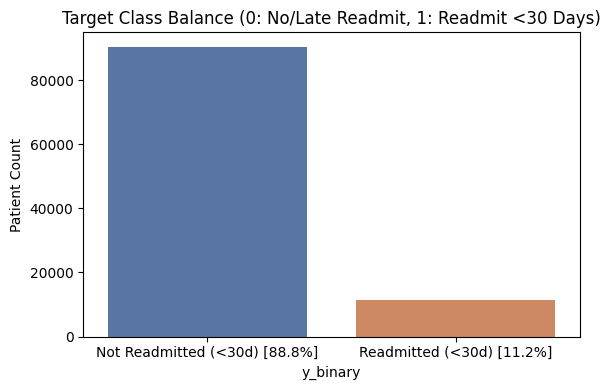

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

df['y_binary'] = y_binary

plt.figure(figsize=(6, 4))
ax = sns.countplot(x='y_binary', data=df, palette=['#4C72B0', '#DD8452'])
plt.title('Target Class Balance (0: No/Late Readmit, 1: Readmit <30 Days)')
plt.xticks([0, 1], ['Not Readmitted (<30d) [88.8%]', 'Readmitted (<30d) [11.2%]'])
plt.ylabel('Patient Count')
plt.tight_layout()
plt.show()

In [ ]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

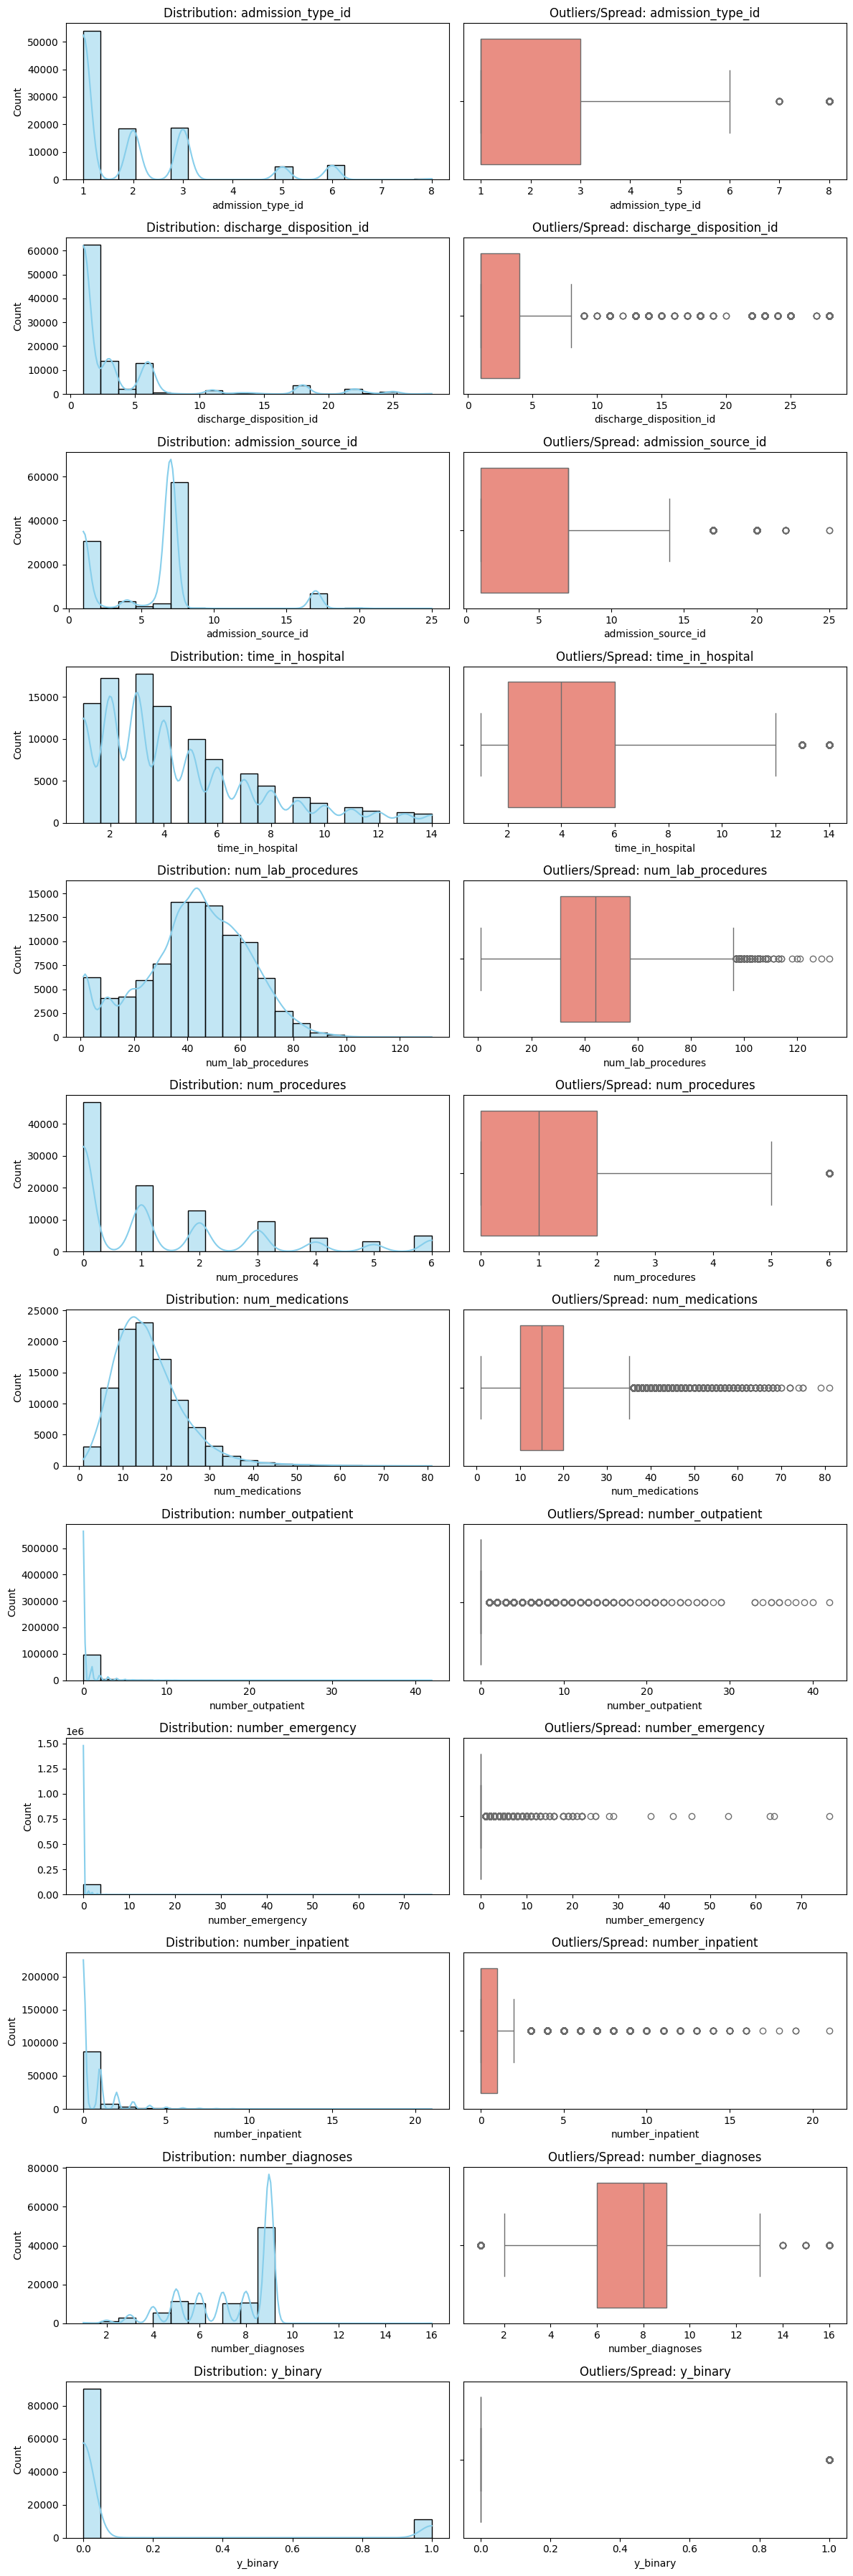

In [ ]:
# Histograms & Boxplots side-by-side for key numerical features
fig, axes = plt.subplots(len(num_cols), 2, figsize=(12, 3 * len(num_cols)))

for i, col in enumerate(num_cols):
    # Histogram
    sns.histplot(df[col], kde=True, ax=axes[i, 0], color='skyblue', bins=20)
    axes[i, 0].set_title(f'Distribution: {col}')

    # Boxplot
    sns.boxplot(x=df[col], ax=axes[i, 1], color='salmon')
    axes[i, 1].set_title(f'Outliers/Spread: {col}')

plt.tight_layout()
plt.show()

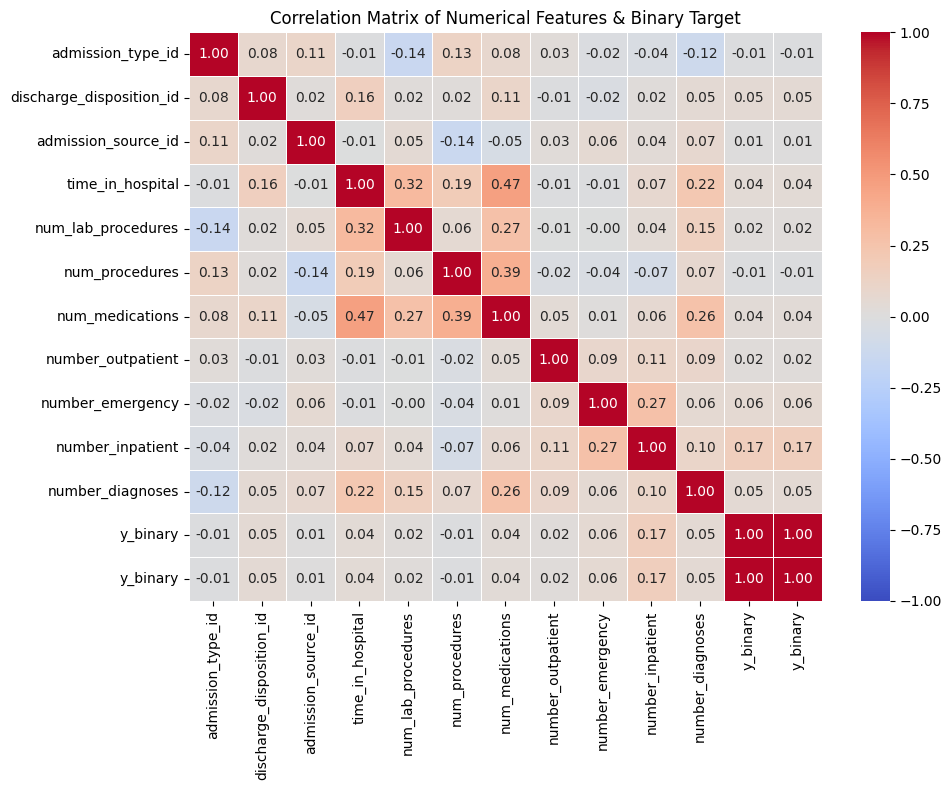

In [ ]:
plt.figure(figsize=(10, 8))
corr = df[num_cols + ['y_binary']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features & Binary Target')
plt.tight_layout()
plt.show()

In [ ]:
# Create a copy for feature engineering
X_fe = df.copy()

# 1. Create Engineered Features
X_fe['total_visits'] = X_fe['number_outpatient'] + X_fe['number_emergency'] + X_fe['number_inpatient']

# Count how many diabetes meds were changed ('Up' or 'Down')
med_cols = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
            'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
            'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
            'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin',
            'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']

X_fe['med_change_count'] = X_fe[med_cols].apply(lambda row: sum(val in ['Up', 'Down'] for val in row), axis=1)

In [ ]:
# 2. Drop High-Missingness & Identifier Columns
drop_cols = ['weight', 'payer_code', 'medical_specialty', 'encounter_id', 'patient_nbr', 'readmitted', 'target_binary']
X_fe = X_fe.drop(columns=[col for col in drop_cols if col in X_fe.columns])

# 3. Frequency Encode High-Cardinality Diagnosis Codes
for col in ['diag_1', 'diag_2', 'diag_3']:
    freq = X_fe[col].value_counts(normalize=True)
    X_fe[f'{col}_freq'] = X_fe[col].map(freq).fillna(0)
    X_fe.drop(columns=[col], inplace=True)

# 4. Fill Categorical NaNs and One-Hot Encode
cat_cols = X_fe.select_dtypes(include=['object']).columns
X_fe[cat_cols] = X_fe[cat_cols].fillna('Missing')
X_engineered = pd.get_dummies(X_fe, columns=cat_cols, drop_first=True)

In [ ]:
print('--- X.info() ---')
X.info()

In [ ]:
print('\n--- X.describe() ---')
display(X.describe(include='all'))

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(x='race', data=X, palette='viridis', order=X['race'].value_counts().index)
plt.title('Distribution of Patient Race in X')
plt.xlabel('Race')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
numerical_cols_X = X.select_dtypes(include=[np.number]).columns

if not numerical_cols_X.empty:
    fig, axes = plt.subplots(nrows=len(numerical_cols_X), ncols=1, figsize=(10, 4 * len(numerical_cols_X)))
    if len(numerical_cols_X) == 1:
        axes = [axes] # Ensure axes is iterable even for a single plot

    for i, col in enumerate(numerical_cols_X):
        sns.boxplot(x=X[col], ax=axes[i], color='skyblue')
        axes[i].set_title(f'Box Plot of {col} in X')
        axes[i].set_xlabel(col)

    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns found in X for box plotting.")

In [ ]:
numerical_cols_X = X.select_dtypes(include=[np.number]).columns

if not numerical_cols_X.empty:
    fig, axes = plt.subplots(nrows=len(numerical_cols_X), ncols=1, figsize=(10, 4 * len(numerical_cols_X)))
    if len(numerical_cols_X) == 1:
        axes = [axes] # Ensure axes is iterable even for a single plot

    for i, col in enumerate(numerical_cols_X):
        sns.histplot(x=X[col], kde=True, ax=axes[i], color='lightgreen', bins=30)
        axes[i].set_title(f'Histogram of {col} in X')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns found in X for histogram plotting.")

In [ ]:
categorical_cols_X = X.select_dtypes(include=['object', 'category']).columns

if not categorical_cols_X.empty:
    # Determine optimal grid size for subplots
    num_plots = len(categorical_cols_X)
    num_cols = 3 # Number of columns for the subplot grid
    num_rows = (num_plots + num_cols - 1) // num_cols

    fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(5 * num_cols, 4 * num_rows))
    # Flatten axes array for easy iteration if there's more than one row/column
    axes = axes.flatten() if num_plots > 1 else [axes]

    for i, col in enumerate(categorical_cols_X):
        sns.countplot(y=X[col], ax=axes[i], palette='pastel', order=X[col].value_counts().index)
        axes[i].set_title(f'Distribution of {col} in X')
        axes[i].set_xlabel('Count')
        axes[i].set_ylabel(col)

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()
else:
    print("No categorical columns found in X for plotting.")

In [ ]:
# Univariate analysis for y ('readmitted' column)
print("Value Counts for 'readmitted' in y:")
display(y['readmitted'].value_counts())

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(x='readmitted', data=y, palette='deep', order=y['readmitted'].value_counts().index)
plt.title('Distribution of Readmission Status (y)')
plt.xlabel('Readmission Status')
plt.ylabel('Count')
plt.tight_layout()
plt.show()